In [1]:
%load_ext autoreload
%autoreload 2
from src import utils

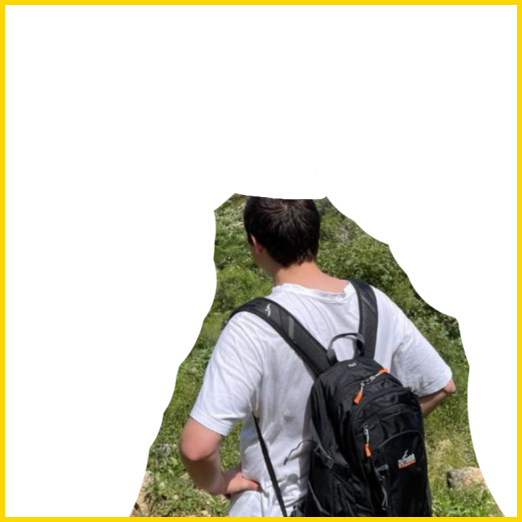

In [7]:
img = utils.open_image("p_0.png")
mask = utils.open_mask("mask_forest.png")
utils.mask_image(img, mask)

In [21]:
from diffusers import StableDiffusionPipeline, DDPMScheduler
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_id = "sd2-community/stable-diffusion-2-base"
pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float16
    ).to(device)

pipe.scheduler = DDPMScheduler.from_config(pipe.scheduler.config)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

In [24]:
from src import repaint

r = repaint.RePaint(pipe)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [ ]:
r.impaint(img,mask,"a picture of a bush").show()

beginning impainting


  2%|█▎                                                                        | 17/1000 [01:35<1:33:41,  5.72s/it]